In [9]:
import numpy as np 

In [10]:
import pandas as pd

In [41]:
df =pd.read_csv("combined_employee_dataset_1.csv")
df.head(10)

,age,years_experience,education_level,department,performance_score,performance_category
0,58,23,High School,Finance,10,Excellent
1,48,39,Bachelor,HR,6,Good
2,34,15,High School,HR,5,Average
3,27,29,PhD,HR,4,Average
4,40,36,PhD,Finance,2,Poor
5,58,13,PhD,Tech,4,Average
6,38,32,PhD,Tech,10,Excellent
7,42,7,PhD,Finance,10,Excellent
8,30,22,Master,HR,3,Poor
9,30,28,Master,HR,10,Excellent


In [12]:
df.shape

(791, 6)

In [13]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   age                   791 non-null    int64
 1   years_experience      791 non-null    int64
 2   education_level       791 non-null    str  
 3   department            791 non-null    str  
 4   performance_score     791 non-null    int64
 5   performance_category  791 non-null    str  
dtypes: int64(3), str(3)
memory usage: 37.2 KB


In [14]:

df.describe()


,age,years_experience,performance_score
count,791.000000,791.000000,791.000000
mean,39.867257,21.031606,5.495575
std,11.867681,11.467412,2.927766
min,20.000000,1.000000,1.000000
25%,29.000000,11.000000,3.000000
50%,41.000000,22.000000,5.000000
75%,51.000000,32.000000,8.000000
max,59.000000,39.000000,10.000000


In [15]:
print(df.isnull().sum())

age                     0
years_experience        0
education_level         0
department              0
performance_score       0
performance_category    0
dtype: int64


In [16]:
print("Total Duplicates:", df.duplicated().sum())

Total Duplicates: 3


In [17]:
df.duplicated().sum()

np.int64(3)

In [18]:
df.dtypes

age                     int64
years_experience        int64
education_level           str
department                str
performance_score       int64
performance_category      str
dtype: object

In [19]:
duplicates = df[df.duplicated()]
print(duplicates)

     age  years_experience education_level department  performance_score  \
159   34                19             PhD      Sales                  1   
218   54                37             PhD    Finance                 10   
755   54                 2     High School         HR                  6   

    performance_category  
159                 Poor  
218            Excellent  
755                 Good  


In [20]:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows.index)

Index([159, 218, 755], dtype='int64')


In [21]:
for col in ['age', 'years_experience', 'performance_score']:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print(lower,upper)

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col}")
    print("Outliers:", len(outliers))

-4.0 84.0

age
Outliers: 0
-20.5 63.5

years_experience
Outliers: 0
-4.5 15.5

performance_score
Outliers: 0


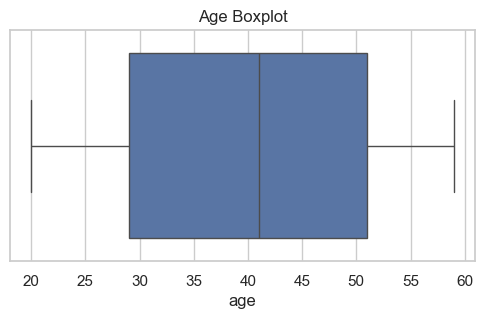

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
sns.boxplot(x=df['age'])
plt.title("Age Boxplot")
plt.show()

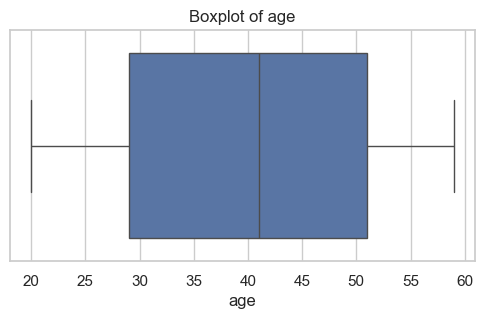

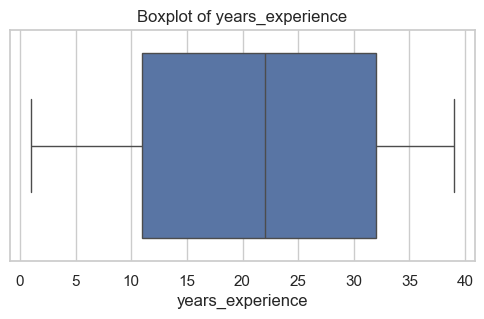

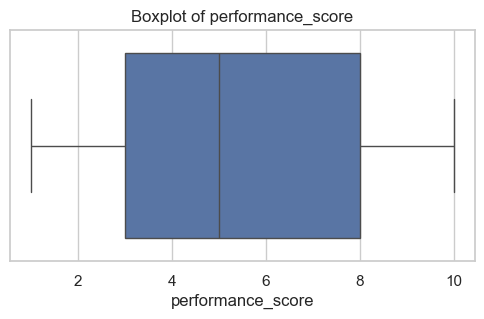

In [23]:


num_cols = ['age', 'years_experience', 'performance_score']

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

#### no outlier or nulL value present inside the Dataset

#### remove dublicates from data

In [24]:
df = df.drop_duplicates()

In [25]:
df.shape

(788, 6)

In [26]:
df.isna().sum()

age                     0
years_experience        0
education_level         0
department              0
performance_score       0
performance_category    0
dtype: int64

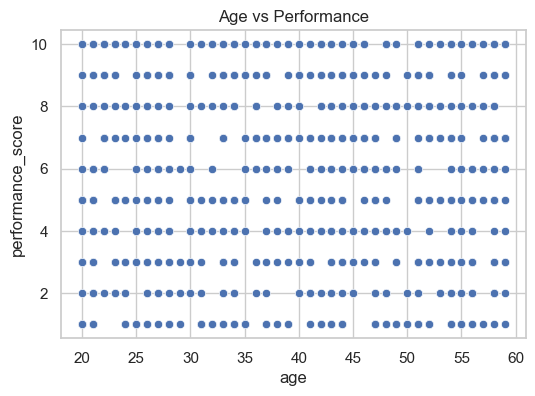

In [27]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='age',
    y='performance_score',
    data=df
)

plt.title('Age vs Performance')
plt.show()

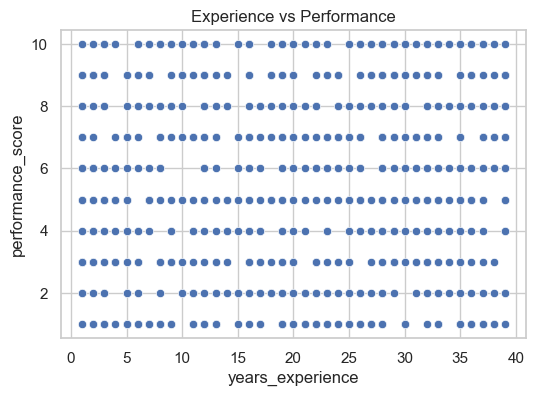

In [28]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='years_experience',
    y='performance_score',
    data=df
)

plt.title('Experience vs Performance')
plt.show()

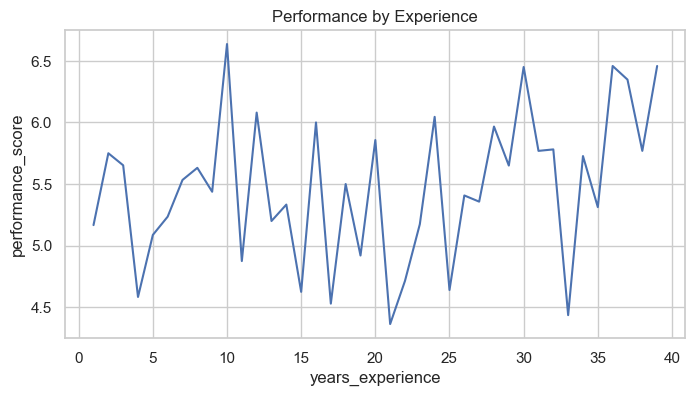

In [29]:
exp_perf = df.groupby(
    'years_experience'
)['performance_score'].mean().reset_index()

plt.figure(figsize=(8,4))

sns.lineplot(
    x='years_experience',
    y='performance_score',
    data=exp_perf
)

plt.title('Performance by Experience')
plt.show()

In [44]:
sns.set_theme(style="whitegrid",palette="dark")
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('employee_dataset_powerbi.csv')
df['Attendance_Percentage'] = df['Attendance_Percentage'].str.replace('%', '').astype(float)

In [45]:
plt.rcParams.update({
    'text.color': 'black',                
    'axes.labelcolor': 'black',          
    'axes.titleweight': 'bold',           
    'axes.labelweight': 'bold',           
    'xtick.color': 'black',               
    'ytick.color': 'black',              
    'axes.titlesize': 15,                 
    'axes.labelsize': 14,                 
})

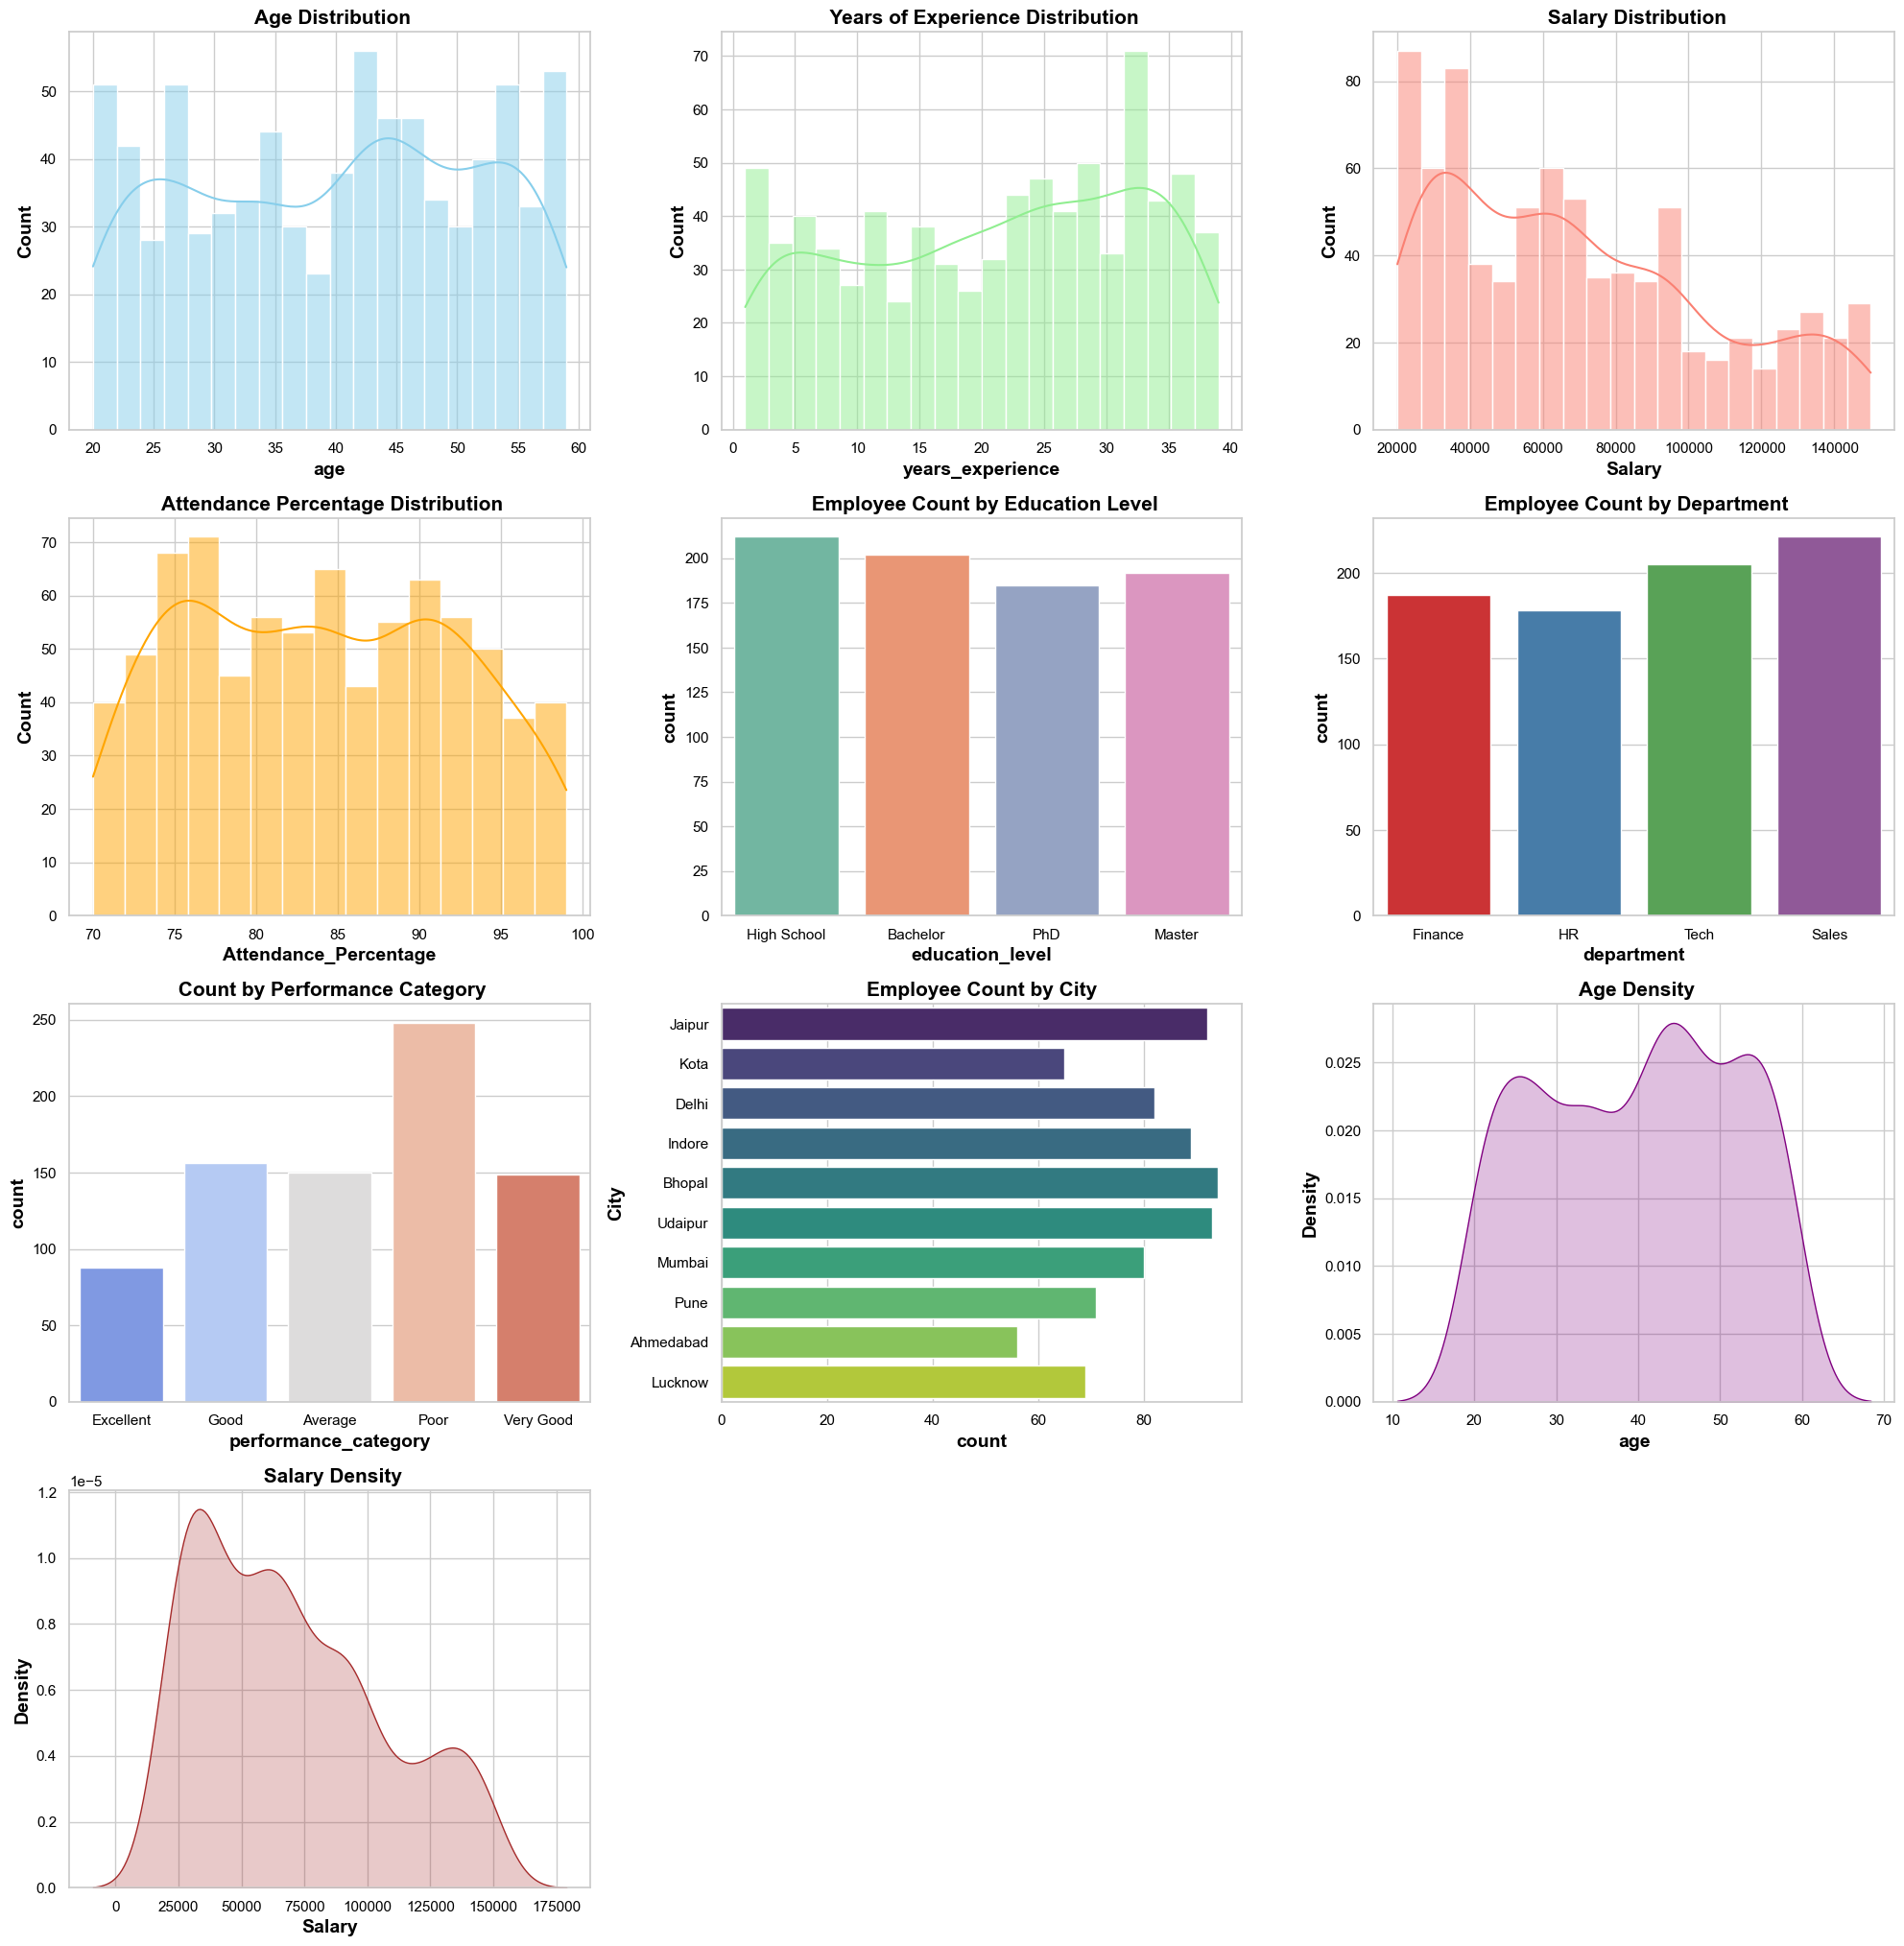

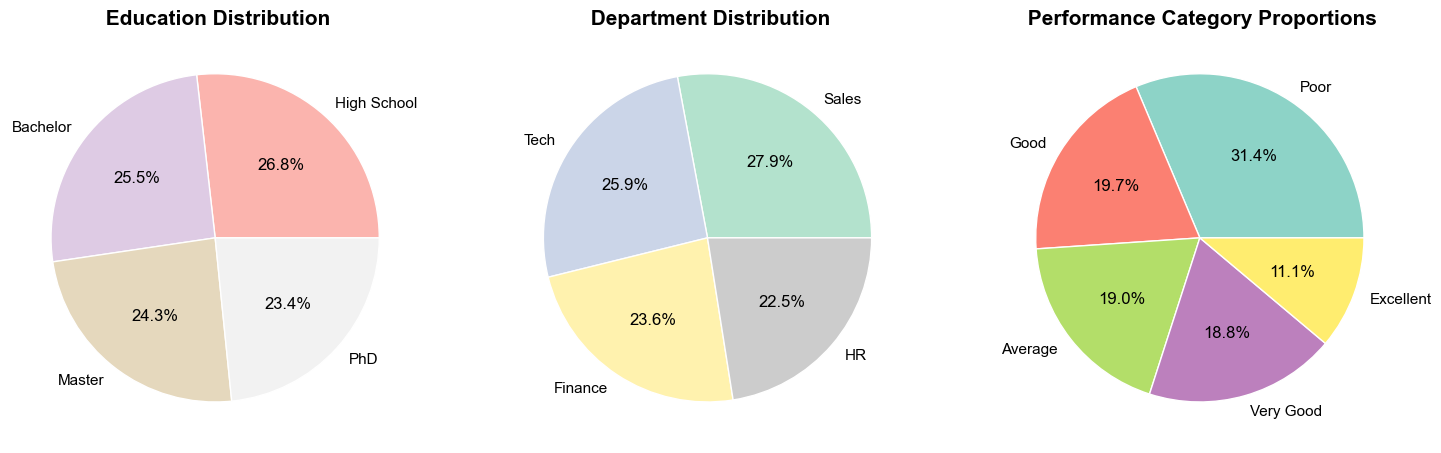

In [46]:
plt.figure(figsize=(20, 25))

plt.subplot(5, 3, 1)
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title(' Age Distribution')

plt.subplot(5, 3, 2)
sns.histplot(df['years_experience'], bins=20, kde=True, color='lightgreen')
plt.title(' Years of Experience Distribution')

plt.subplot(5, 3, 3)
sns.histplot(df['Salary'], bins=20, kde=True, color='salmon')
plt.title(' Salary Distribution')

plt.subplot(5, 3, 4)
sns.histplot(df['Attendance_Percentage'], bins=15, kde=True, color='orange')
plt.title(' Attendance Percentage Distribution')

plt.subplot(5, 3, 5)
sns.countplot(x='education_level', data=df, palette='Set2')
plt.title(' Employee Count by Education Level')

plt.subplot(5, 3, 6)
sns.countplot(x='department', data=df, palette='Set1')
plt.title(' Employee Count by Department')

plt.subplot(5, 3, 7)
sns.countplot(x='performance_category', data=df, palette='coolwarm')
plt.title(' Count by Performance Category')

plt.subplot(5, 3, 8)
sns.countplot(y='City', data=df, palette='viridis')
plt.title('Employee Count by City')

plt.subplot(5, 3, 9)
sns.kdeplot(df['age'], fill=True, color='purple')
plt.title(' Age Density')

plt.subplot(5, 3, 10)
sns.kdeplot(df['Salary'], fill=True, color='brown')
plt.title(' Salary Density')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
df['education_level'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], cmap='Pastel1', title=' Education Distribution')
df['department'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], cmap='Pastel2', title=' Department Distribution')
df['performance_category'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[2], cmap='Set3', title=' Performance Category Proportions')
axes[0].set_ylabel(''); axes[1].set_ylabel(''); axes[2].set_ylabel('')
plt.show()

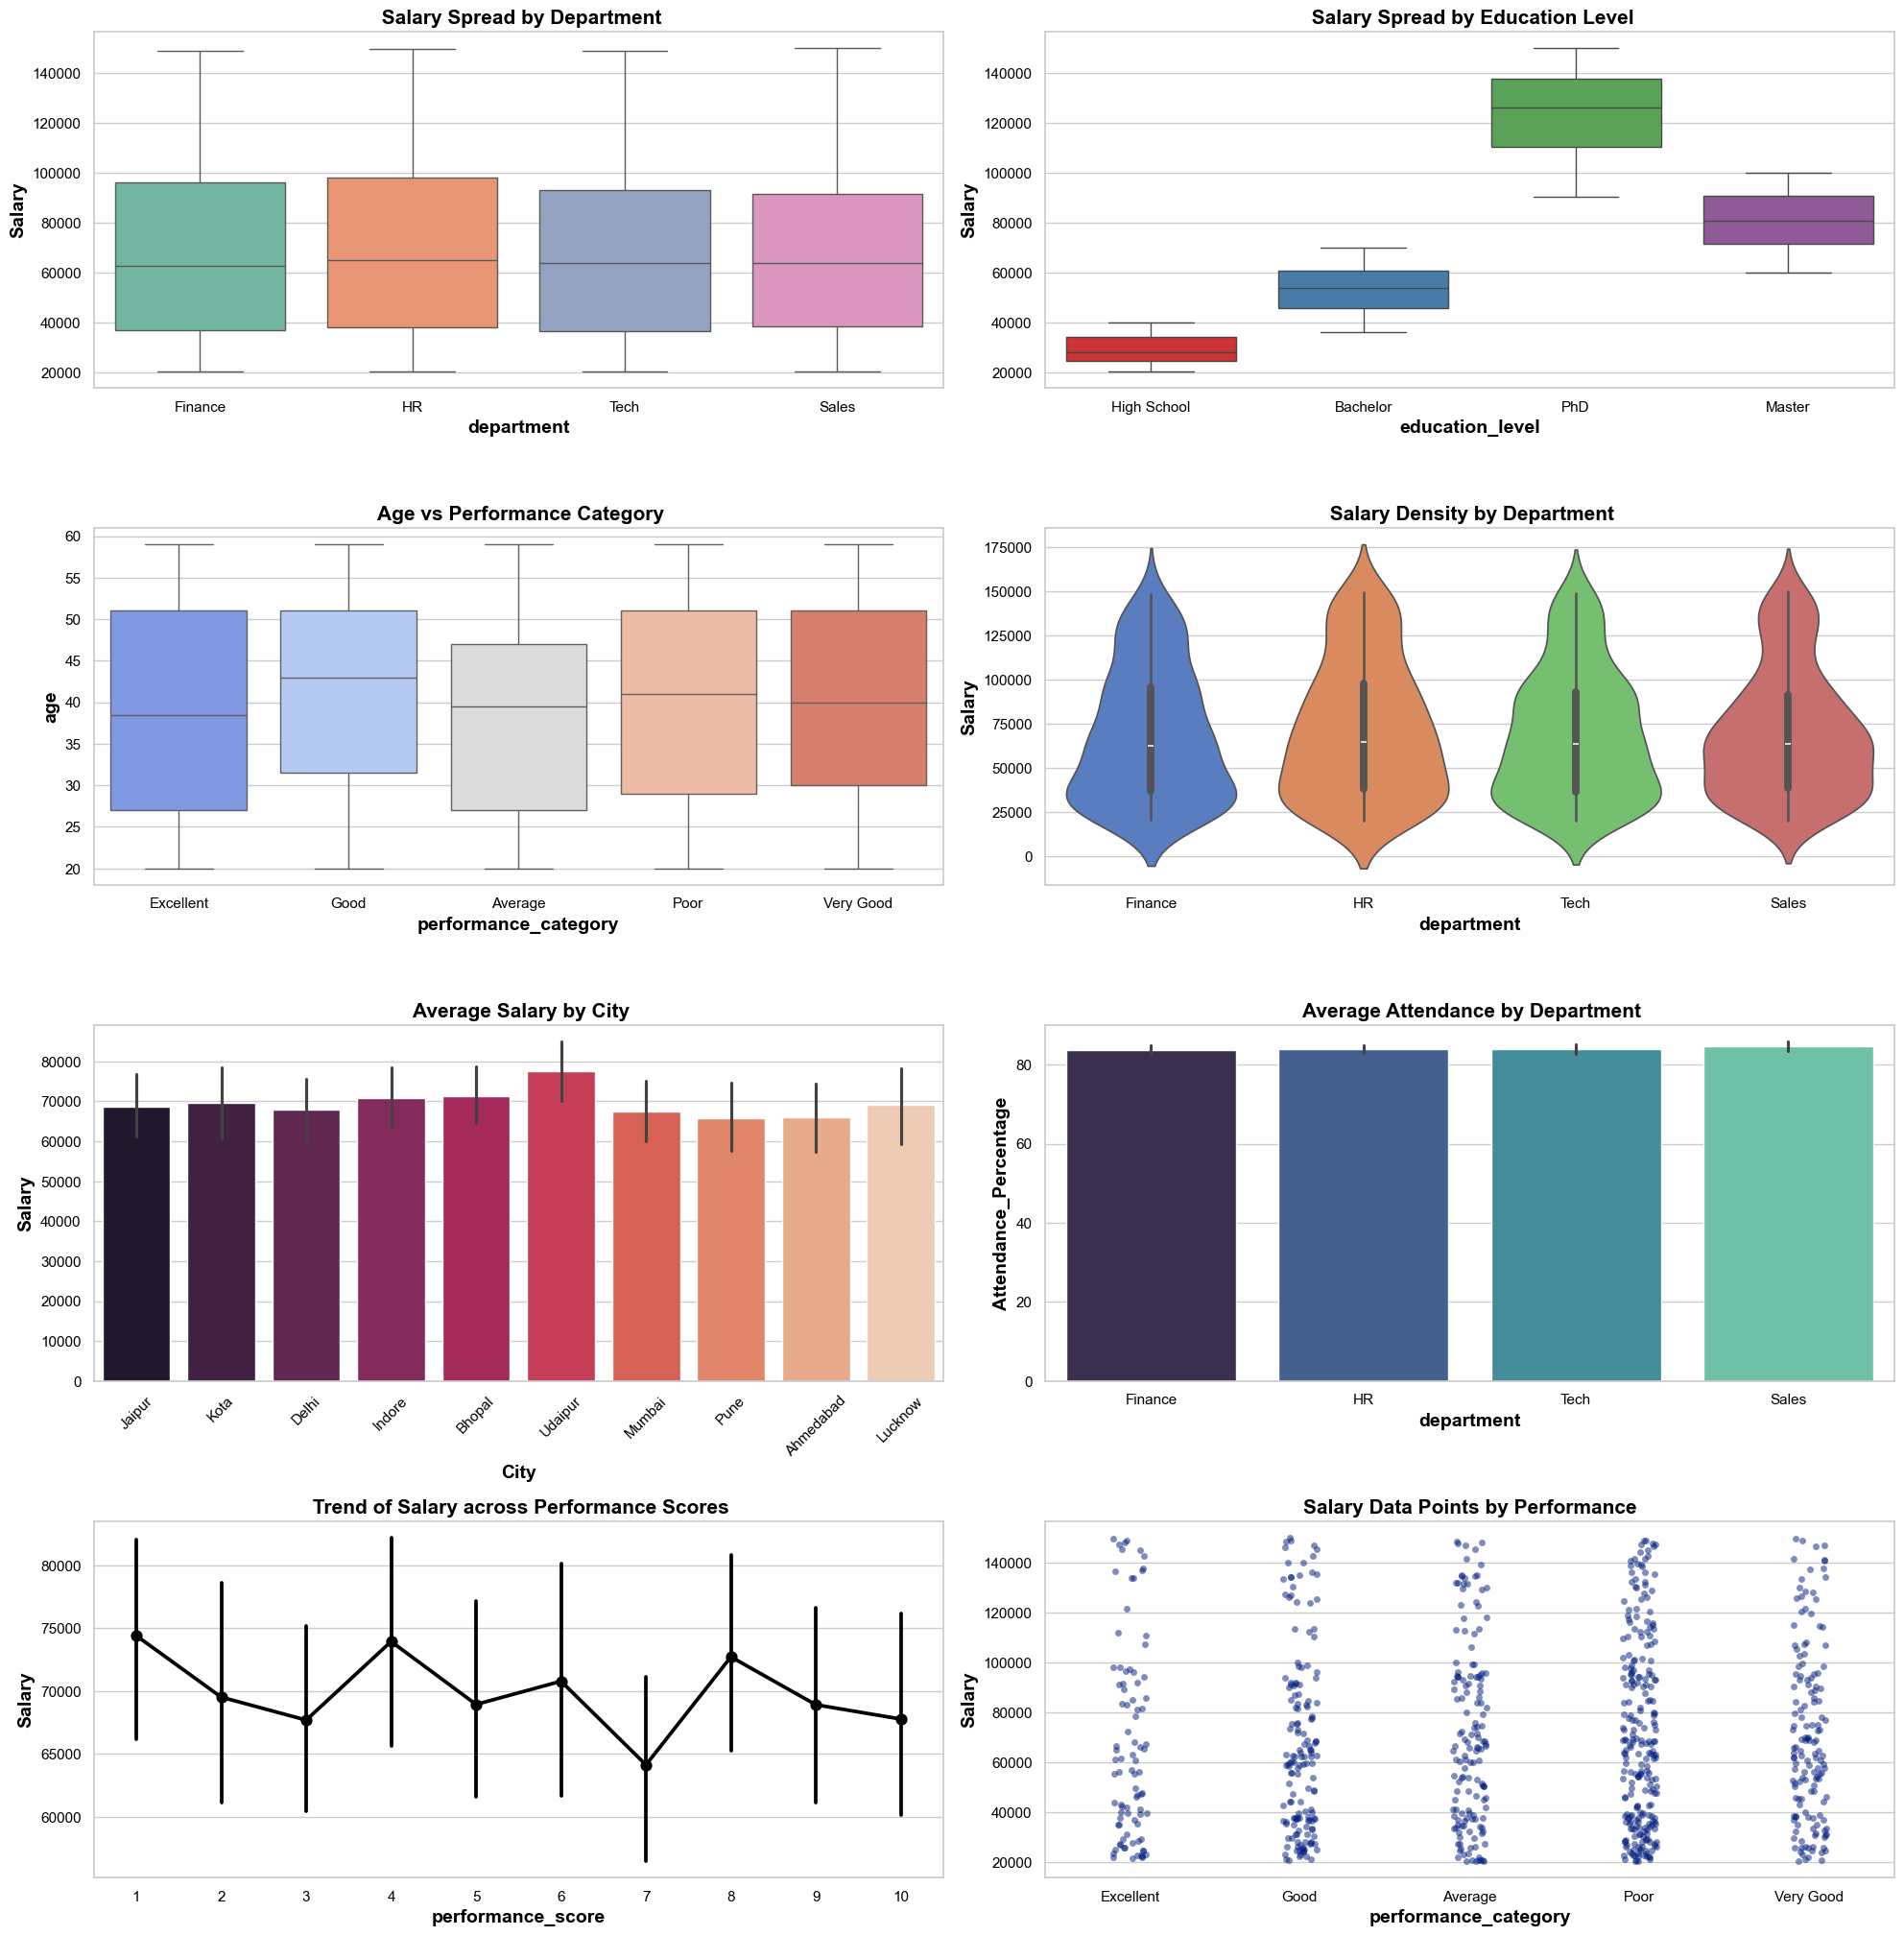

In [47]:
plt.figure(figsize=(20, 25))

plt.subplot(5, 2, 1)
sns.boxplot(x='department', y='Salary', data=df, palette='Set2')
plt.title(' Salary Spread by Department')

plt.subplot(5, 2, 2)
sns.boxplot(x='education_level', y='Salary', data=df, palette='Set1')
plt.title(' Salary Spread by Education Level')

plt.subplot(5, 2, 3)
sns.boxplot(x='performance_category', y='age', data=df, palette='coolwarm')
plt.title(' Age vs Performance Category')

plt.subplot(5, 2, 4)
sns.violinplot(x='department', y='Salary', data=df, palette='muted')
plt.title(' Salary Density by Department')

plt.subplot(5, 2, 5)
sns.barplot(x='City', y='Salary', data=df, estimator=np.mean, palette='rocket')
plt.title(' Average Salary by City')
plt.xticks(rotation=45)

plt.subplot(5, 2, 6)
sns.barplot(x='department', y='Attendance_Percentage', data=df, palette='mako')
plt.title(' Average Attendance by Department')

plt.subplot(5, 2, 7)
sns.pointplot(x='performance_score', y='Salary', data=df, color='black')
plt.title(' Trend of Salary across Performance Scores')

plt.subplot(5, 2, 8)
sns.stripplot(x='performance_category', y='Salary', data=df, jitter=True, alpha=0.5)
plt.title('Salary Data Points by Performance')

plt.tight_layout()
plt.show()

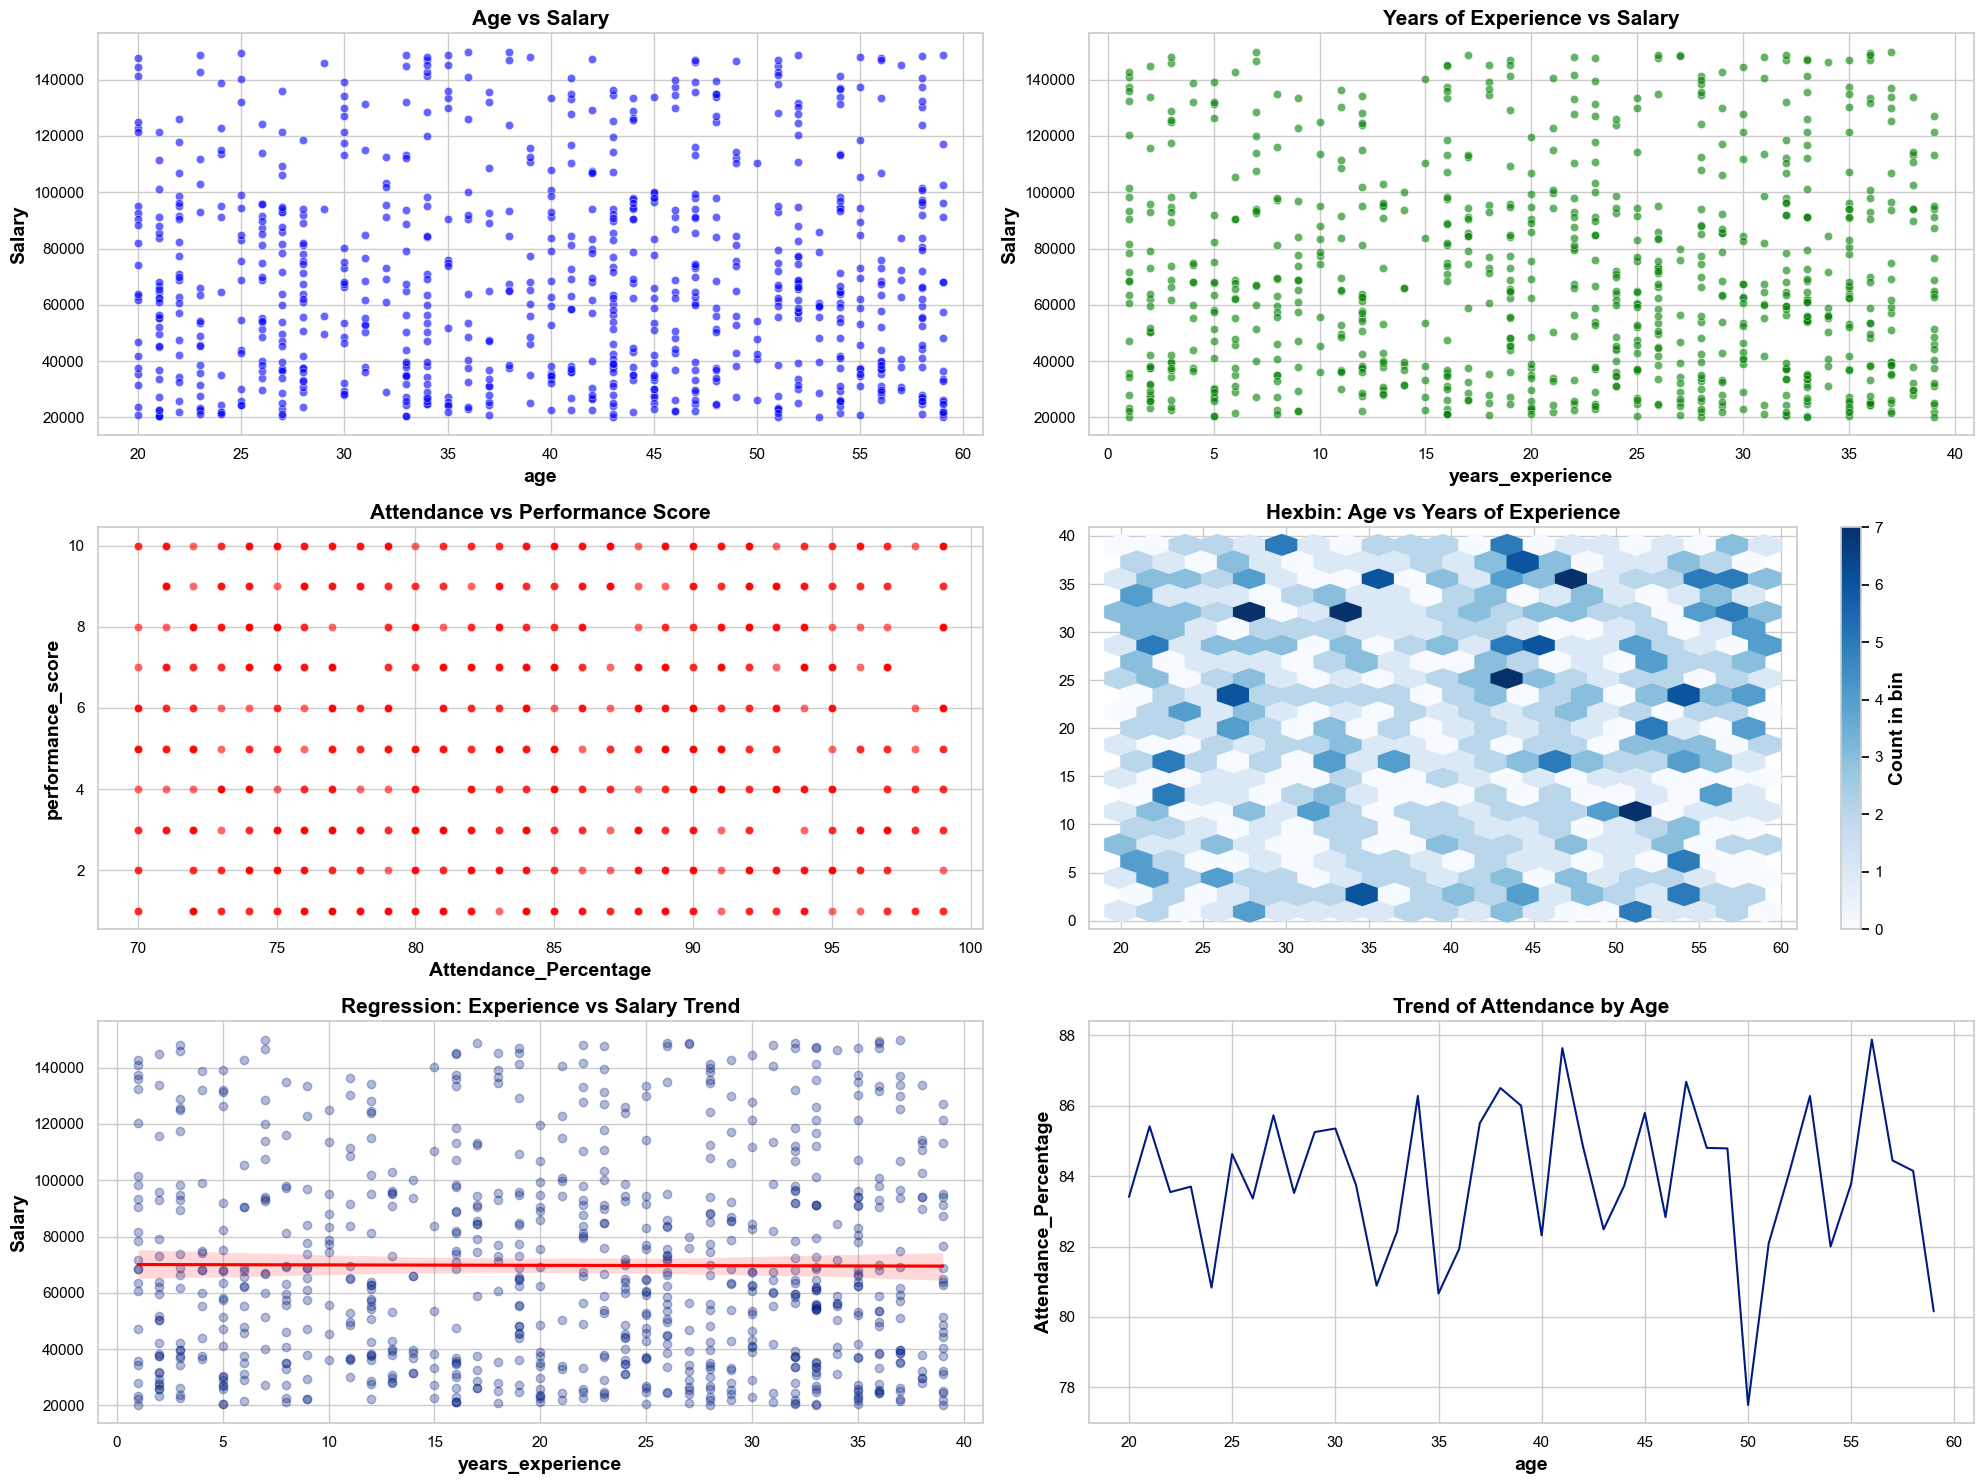

In [48]:
plt.figure(figsize=(20, 15))

plt.subplot(3, 2, 1)
sns.scatterplot(x='age', y='Salary', data=df, alpha=0.6, color='blue')
plt.title('Age vs Salary')

plt.subplot(3, 2, 2)
sns.scatterplot(x='years_experience', y='Salary', data=df, alpha=0.6, color='green')
plt.title('Years of Experience vs Salary')

plt.subplot(3, 2, 3)
sns.scatterplot(x='Attendance_Percentage', y='performance_score', data=df, alpha=0.6, color='red')
plt.title('Attendance vs Performance Score')

plt.subplot(3, 2, 4)
plt.hexbin(df['age'], df['years_experience'], gridsize=20, cmap='Blues')
plt.colorbar(label='Count in bin')
plt.title('Hexbin: Age vs Years of Experience')

plt.subplot(3, 2, 5)
sns.regplot(x='years_experience', y='Salary', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Regression: Experience vs Salary Trend')

plt.subplot(3, 2, 6)
sns.lineplot(x='age', y='Attendance_Percentage', data=df, errorbar=None)
plt.title('Trend of Attendance by Age')

plt.tight_layout()
plt.show()

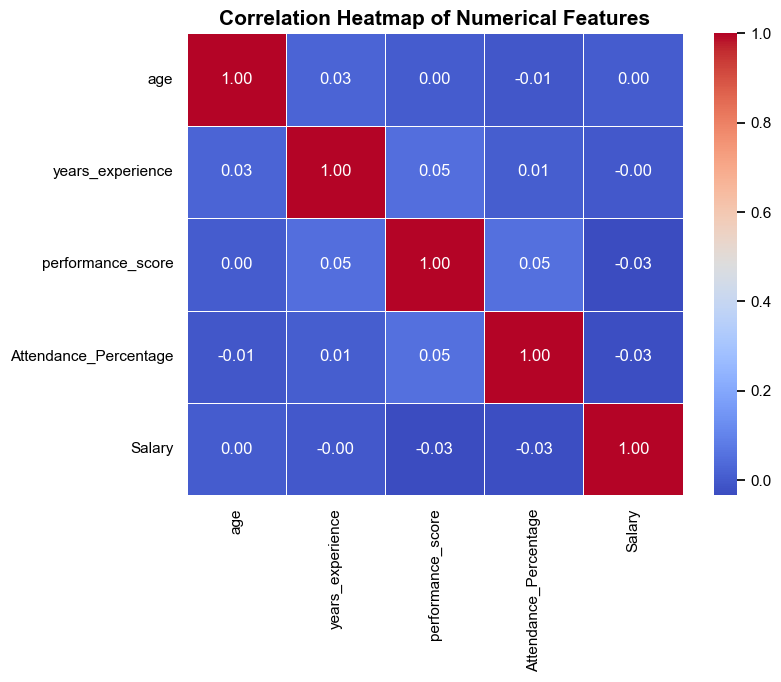

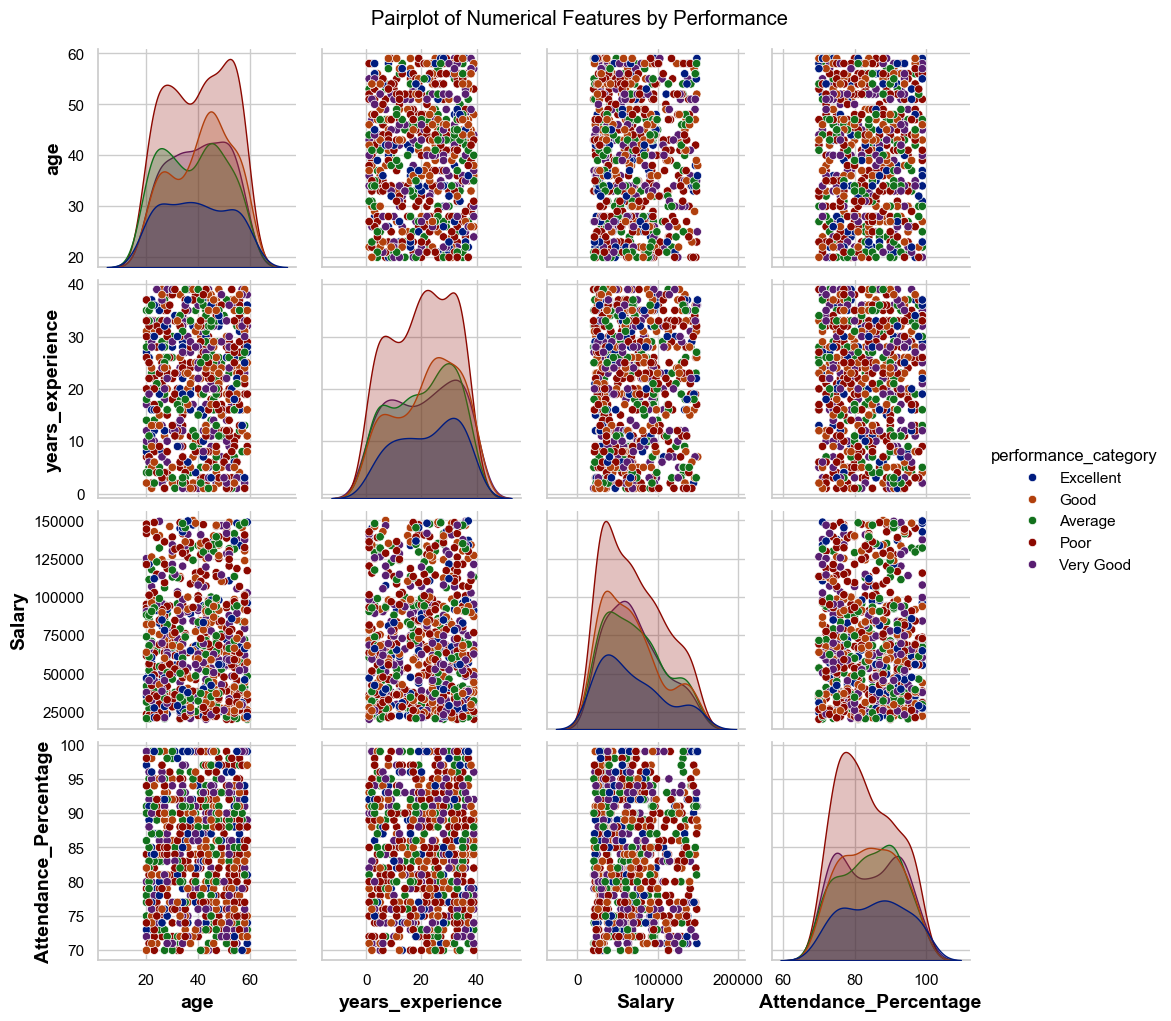

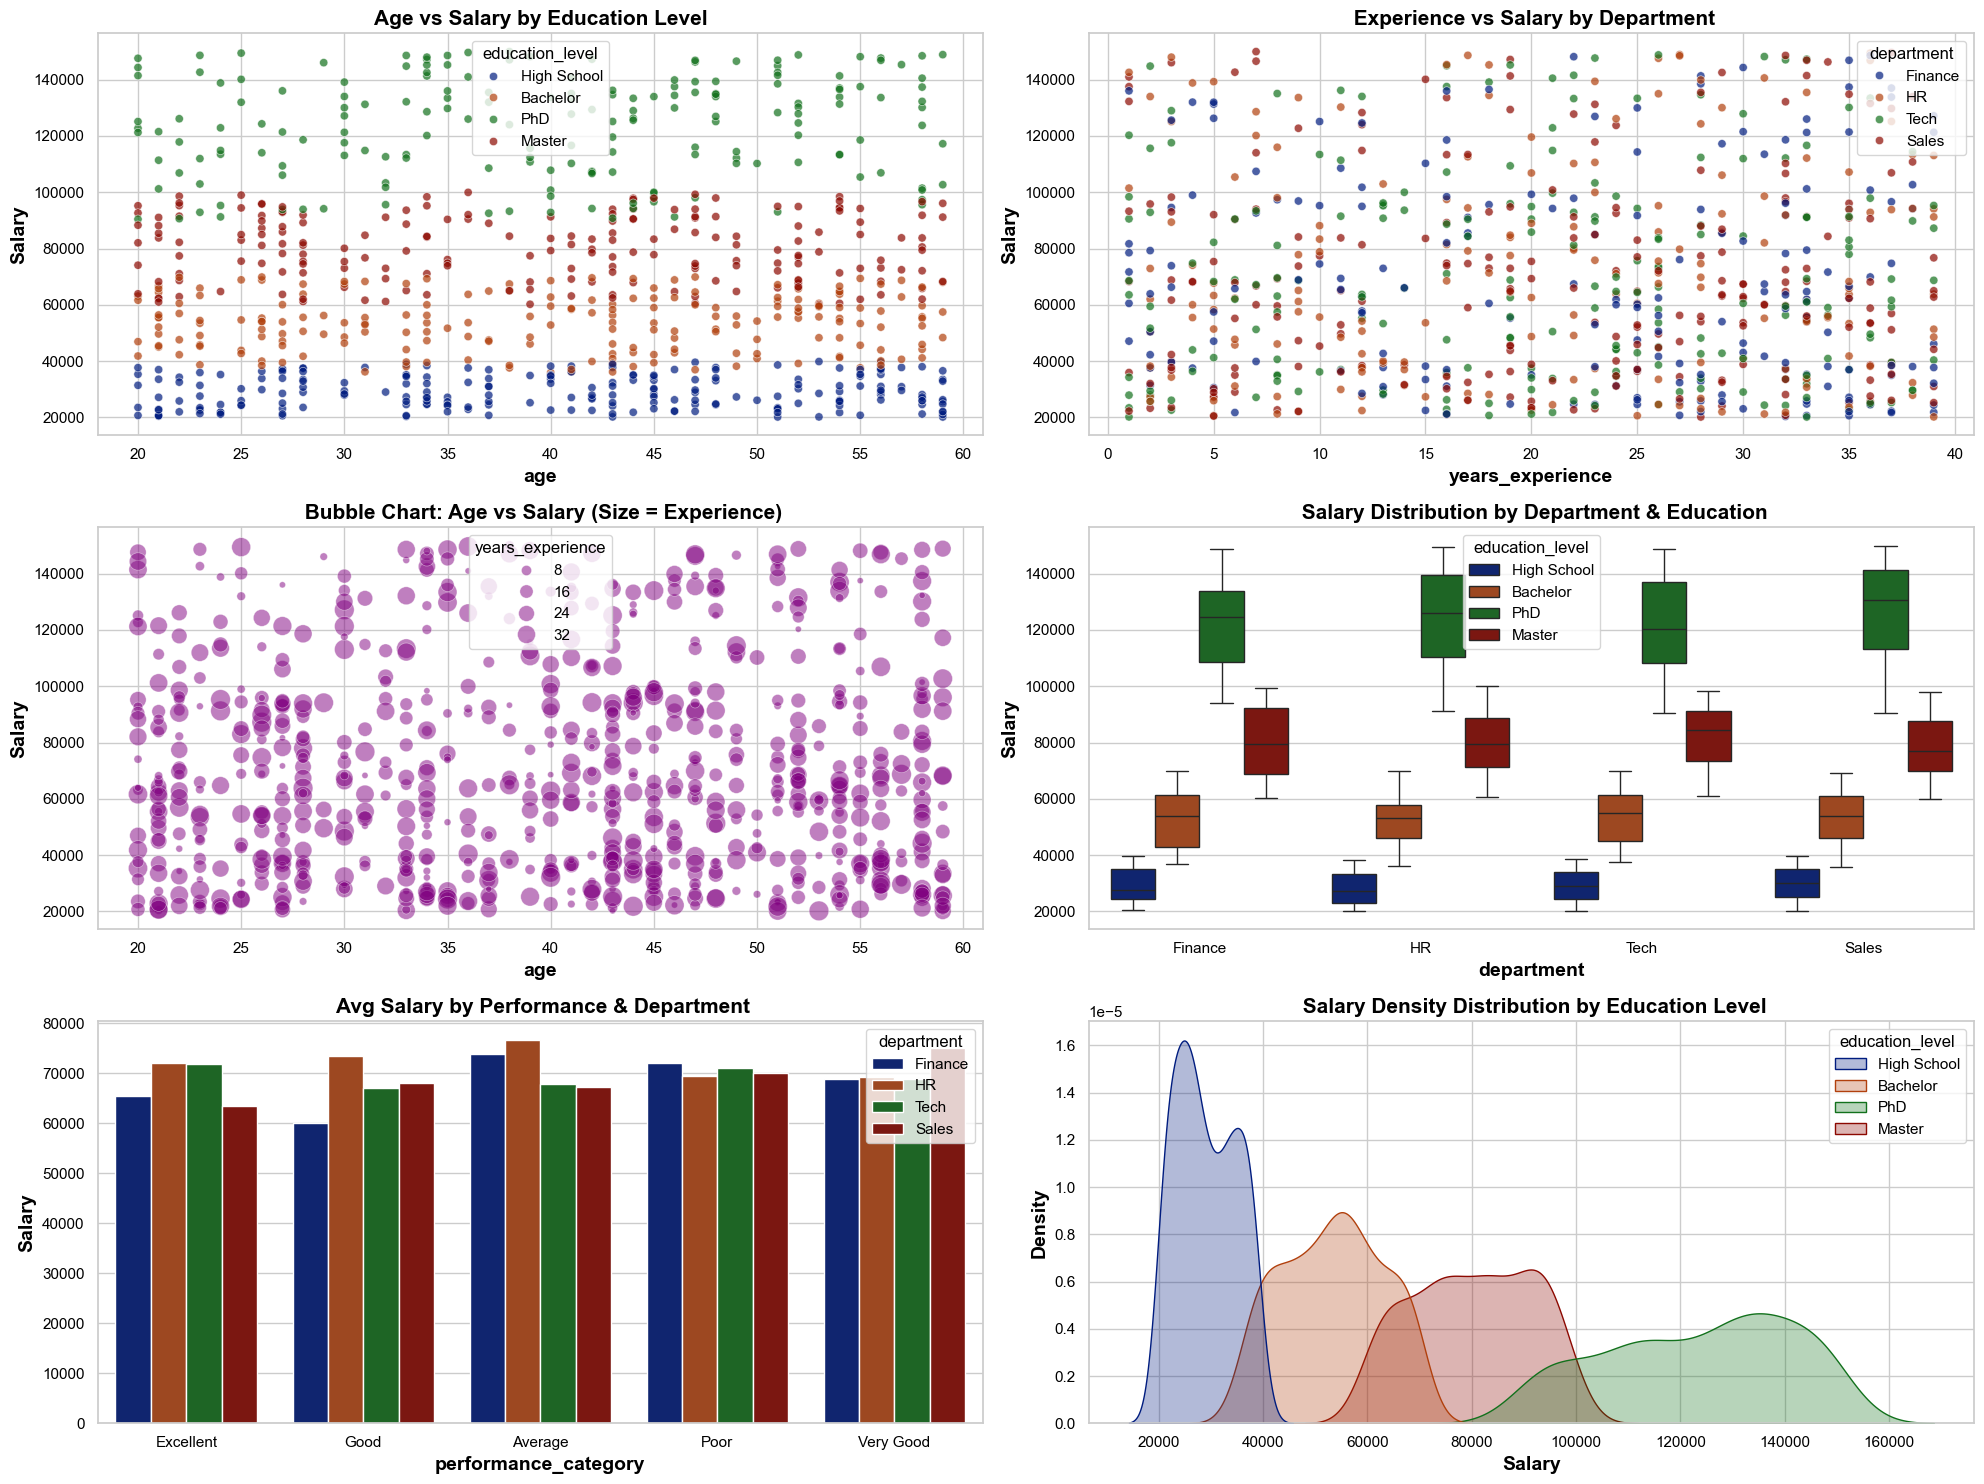

In [49]:

plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

sns.pairplot(df[['age', 'years_experience', 'Salary', 'Attendance_Percentage', 'performance_category']], hue='performance_category')
plt.suptitle('Pairplot of Numerical Features by Performance', y=1.02)
plt.show()

plt.figure(figsize=(20, 15))

plt.subplot(3, 2, 1)
sns.scatterplot(x='age', y='Salary', hue='education_level', data=df, alpha=0.7)
plt.title('Age vs Salary by Education Level')

plt.subplot(3, 2, 2)
sns.scatterplot(x='years_experience', y='Salary', hue='department', data=df, alpha=0.7)
plt.title(' Experience vs Salary by Department')

plt.subplot(3, 2, 3)
sns.scatterplot(x='age', y='Salary', size='years_experience', sizes=(20, 200), alpha=0.5, data=df, color='purple')
plt.title(' Bubble Chart: Age vs Salary (Size = Experience)')

plt.subplot(3, 2, 4)
sns.boxplot(x='department', y='Salary', hue='education_level', data=df)
plt.title(' Salary Distribution by Department & Education')

plt.subplot(3, 2, 5)
sns.barplot(x='performance_category', y='Salary', hue='department', data=df, errorbar=None)
plt.title(' Avg Salary by Performance & Department')

plt.subplot(3, 2, 6)
sns.kdeplot(data=df, x='Salary', hue='education_level', fill=True, alpha=0.3)
plt.title(' Salary Density Distribution by Education Level')

plt.tight_layout()
plt.show()

In [7]:
!pip install squarify


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


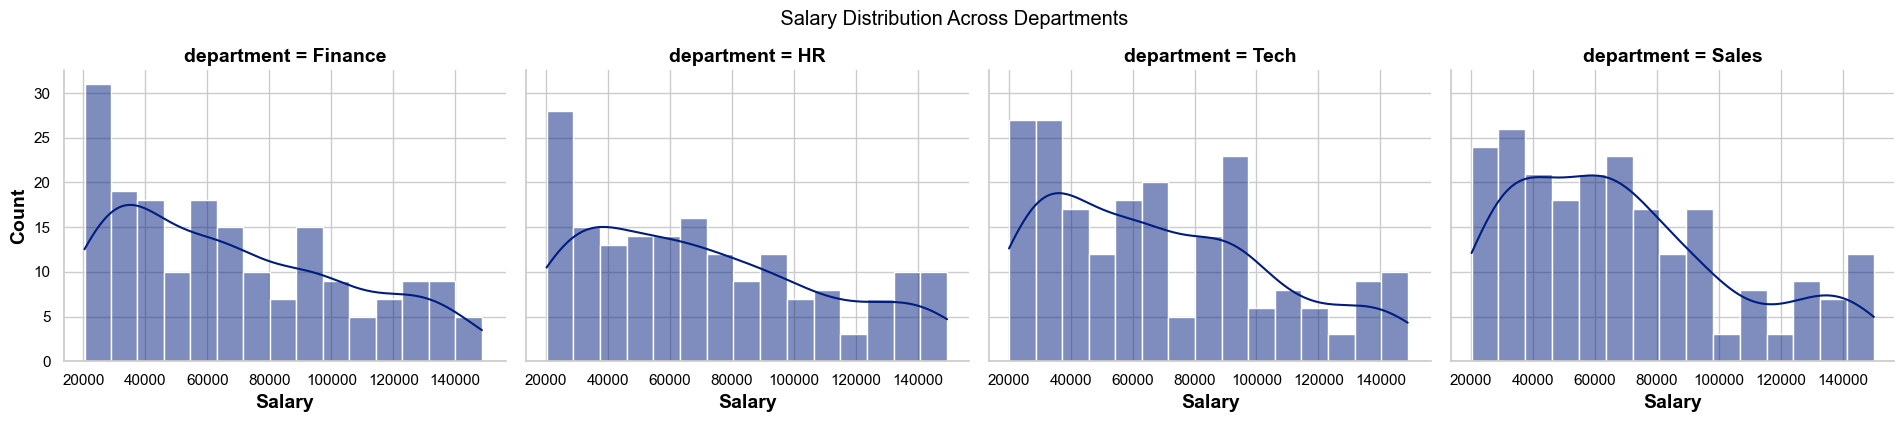

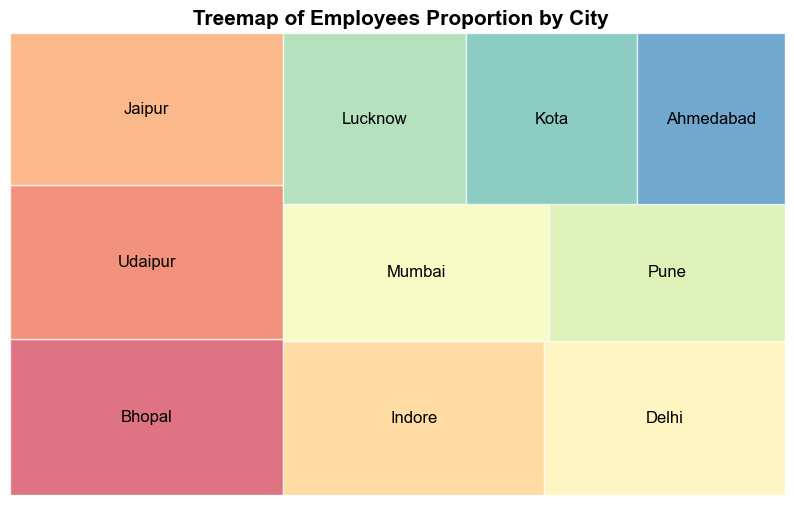

In [50]:
import squarify 

g = sns.FacetGrid(df, col="department", height=4, aspect=1.2)
g.map(sns.histplot, "Salary", bins=15, kde=True)
g.fig.suptitle(' Salary Distribution Across Departments', y=1.05)
plt.show()
plt.figure(figsize=(10, 6))
city_counts = df['City'].value_counts()
squarify.plot(sizes=city_counts.values, label=city_counts.index, alpha=0.7, color=sns.color_palette("Spectral", len(city_counts)))
plt.title(' Treemap of Employees Proportion by City')
plt.axis('off')
plt.show()

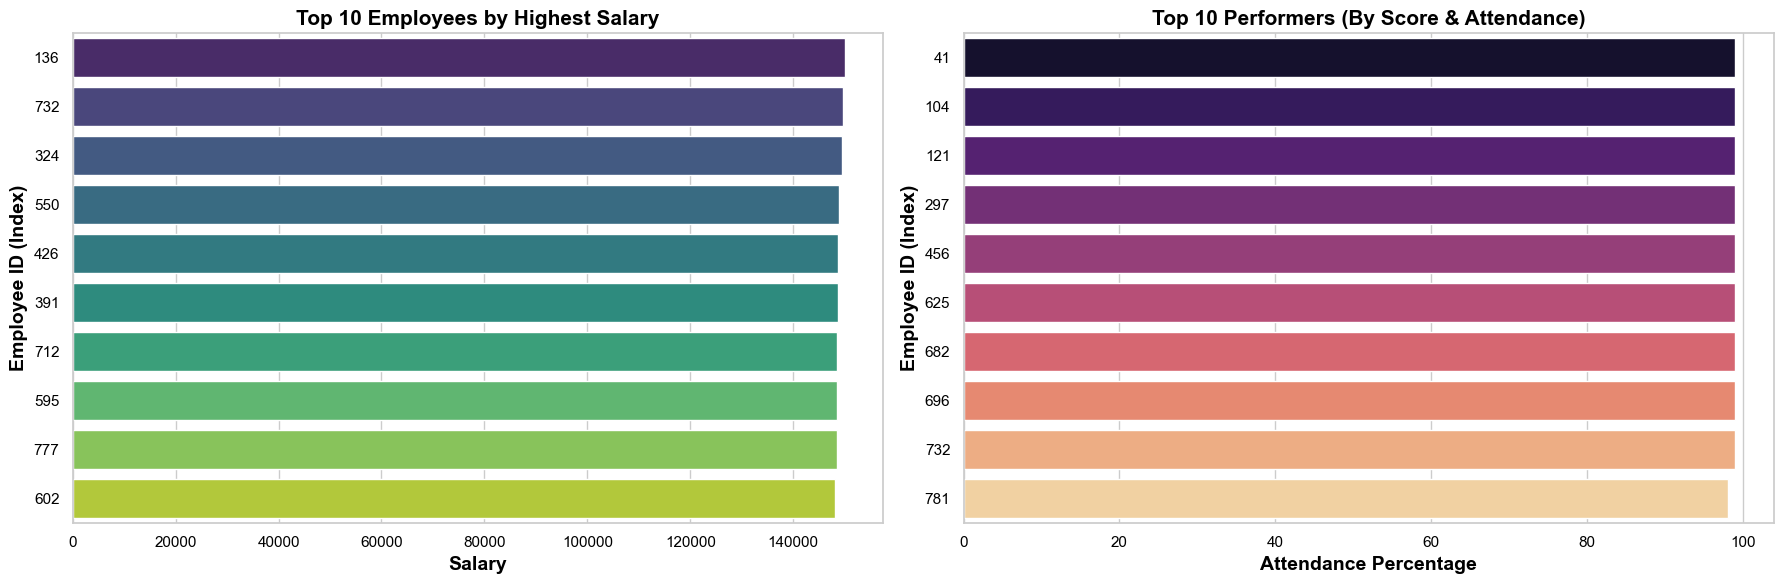

In [52]:

df.columns = df.columns.str.strip()
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
top10_salary = df.nlargest(10, 'Salary')
sns.barplot(x='Salary', y=top10_salary.index.astype(str), data=top10_salary, palette='viridis')
plt.title('Top 10 Employees by Highest Salary', fontweight='bold', color='black')
plt.xlabel('Salary', fontweight='bold', color='black')
plt.ylabel('Employee ID (Index)', fontweight='bold', color='black')
plt.subplot(1, 2, 2)
top10_performers = df.nlargest(10, ['performance_score', 'Attendance_Percentage'])
sns.barplot(x='Attendance_Percentage', y=top10_performers.index.astype(str), data=top10_performers, palette='magma')
plt.title('Top 10 Performers (By Score & Attendance)', fontweight='bold', color='black')
plt.xlabel('Attendance Percentage', fontweight='bold', color='black')
plt.ylabel('Employee ID (Index)', fontweight='bold', color='black')

plt.tight_layout()
plt.show()